<a href="https://colab.research.google.com/github/anushyagande-bot/Student-Performance-Prediction/blob/main/Student_Performance_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install kaggle

In [12]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp "kaggle (1).json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [13]:
!kaggle datasets list

ref                                                                 title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset              Screen Time, Sleep & Stress Analysis Dataset           787136  2026-02-13 06:56:18.757000          11232        228  1.0              
amar5693/student-performance-dataset                                Student Performance Dataset                            177286  2026-02-12 06:04:44.613000           9672        153  1.0              
shree0910/online-vs-in-store-shopping-behaviour-dataset             Online vs In-Store Shopping Behaviour Dataset          354896  2026-02-18 08:16:20.137000           1034         24  1.0

In [14]:
!kaggle datasets download -d uciml/student-alcohol-consumption

Dataset URL: https://www.kaggle.com/datasets/uciml/student-alcohol-consumption
License(s): CC0-1.0
  0% 0.00/18.4k [00:00<?, ?B/s]
100% 18.4k/18.4k [00:00<00:00, 72.1MB/s]


In [15]:
import zipfile

with zipfile.ZipFile("student-alcohol-consumption.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [23]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=",")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [25]:
df['Result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [26]:
X = df[['studytime', 'failures', 'absences']]
y = df['Result']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7341772151898734


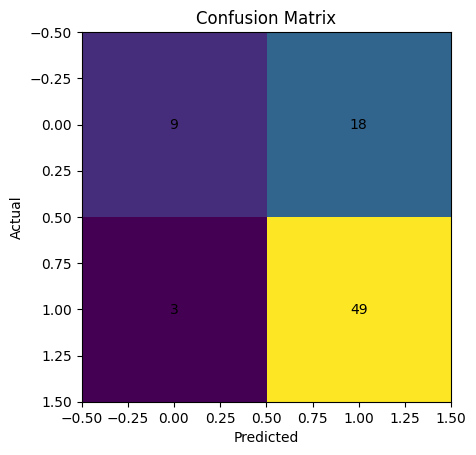

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [32]:
import pandas as pd

# Take input
study = int(input("Enter Study Time (1-4): "))
fail = int(input("Enter Number of Past Failures: "))
absent = int(input("Enter Number of Absences: "))

# Create DataFrame with correct column names
new_student = pd.DataFrame(
    [[study, fail, absent]],
    columns=X_train.columns   # Uses same column names as training data
)

# Predict
prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

# Output result
if prediction[0] == 1:
    print("Result: PASS")
else:
    print("Result: FAIL")

print("Confidence:", round(max(probability[0]) * 100, 2), "%")

Enter Study Time (1-4): 3
Enter Number of Past Failures: 50
Enter Number of Absences: 5
Result: FAIL
Confidence: 100.0 %
